In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
df_usd_inr=pd.read_pickle("df_usd_inr.pkl")
df_cpi=pd.read_pickle("df_cpi.pkl")
df_cpi_usa=pd.read_pickle("df_cpi_usa.pkl")

In [6]:
df_usd_inr.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Returns'], dtype='object')

In [7]:
df_cpi.columns

Index(['sector', 'year', 'month', 'cereals_and_products', 'meat_and_fish',
       'egg', 'milk_and_products', 'oils_and_fats', 'fruits', 'vegetables',
       'pulses_and_products', 'sugar_and_confectionery', 'spices',
       'non-alcoholic_beverages', 'prepared_meals_snacks_sweets_etc.',
       'food_and_beverages', 'pan_tobacco_and_intoxicants', 'clothing',
       'footwear', 'clothing_and_footwear', 'housing', 'fuel_and_light',
       'household_goods_and_services', 'health', 'transport_and_communication',
       'recreation_and_amusement', 'education', 'personal_care_and_effects',
       'miscellaneous', 'general_index', 'date'],
      dtype='object')

In [8]:
df_cpi_usa.columns

Index(['DATE', 'CPI_Overall', 'Inflation'], dtype='object')

## Inflation Differential based on purchasing power parity (PPP)

In [9]:
df_cpi_usa = df_cpi_usa.rename(columns={'DATE': 'date', 'CPI_Overall': 'CPI_US'})
df_cpi = df_cpi.rename(columns={'general_index': 'CPI_India'})

In [10]:
df_inflation = pd.merge(
    df_cpi[['date', 'CPI_India']],
    df_cpi_usa[['date', 'CPI_US']],
    on='date',
    how='inner'
)

In [11]:
df_inflation['Inflation_Diff'] = df_inflation['CPI_India'] - df_inflation['CPI_US']

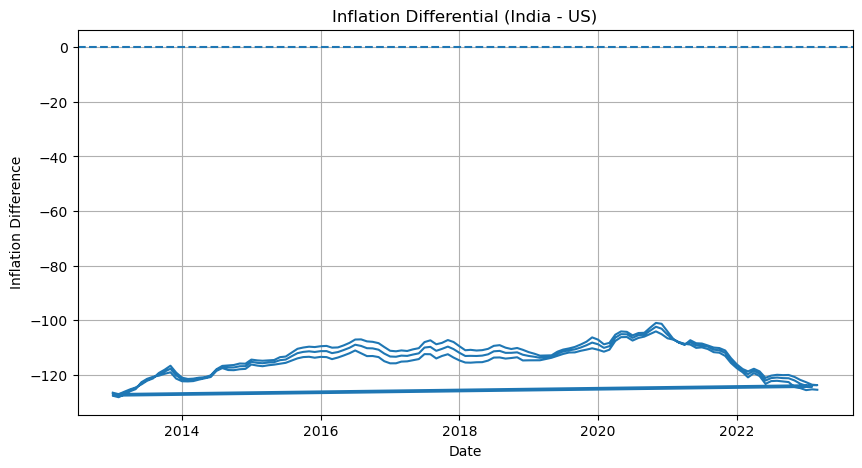

In [14]:
plt.figure(figsize=(10,5))
plt.plot(df_inflation['date'], df_inflation['Inflation_Diff'])

plt.axhline(0, linestyle='--')

plt.title("Inflation Differential (India - US)")
plt.xlabel("Date")
plt.ylabel("Inflation Difference")

plt.grid()
plt.show()

Since graph is below Zero line, US inflation is higher

In [16]:
combined = pd.merge(
    df_inflation,
    df_usd_inr,
    left_on='date',
    right_on='Date',
    how='inner'
)

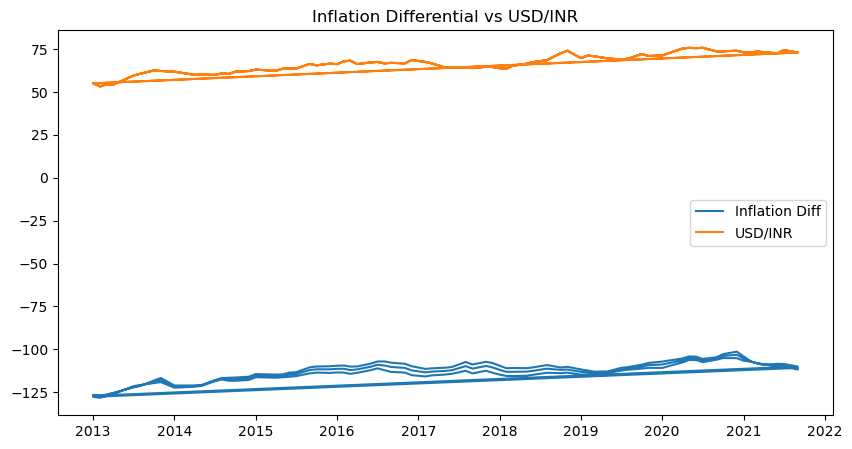

In [17]:
plt.figure(figsize=(10,5))

plt.plot(combined['date'], combined['Inflation_Diff'], label='Inflation Diff')
plt.plot(combined['date'], combined['Close'], label='USD/INR')

plt.legend()
plt.title("Inflation Differential vs USD/INR")
plt.show()

As both lines move together, i.e., Inflation Diff ↑, USD/INR ↑
Higher inflation in India -> INR weakens
So, Purchasing power parity holds

PPP=> If prices rise faster in one country than another, its currency should lose value (depreciate)

In [18]:
print(combined[['Inflation_Diff', 'Close']].corr())

                Inflation_Diff     Close
Inflation_Diff        1.000000  0.863793
Close                 0.863793  1.000000


So, correlation between Inflation_Diff and USD/INR is positive (+0.863). 
=> When inflation in India increases (relative to US), USD/INR also increases 

## Lag Analysis

In [20]:
combined['Inflation_Diff_lag1'] = combined['Inflation_Diff'].shift(1)
combined['Inflation_Diff_lag2'] = combined['Inflation_Diff'].shift(2)

In [21]:
lag_df = combined.dropna().copy()

In [22]:
print(lag_df[['Close', 'Inflation_Diff_lag1', 'Inflation_Diff_lag2']].corr())

                        Close  Inflation_Diff_lag1  Inflation_Diff_lag2
Close                1.000000             0.818271             0.751486
Inflation_Diff_lag1  0.818271             1.000000             0.927069
Inflation_Diff_lag2  0.751486             0.927069             1.000000


In [25]:
X = lag_df[['Inflation_Diff_lag1', 'Inflation_Diff_lag2']]
y = lag_df['Close']

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("R^2:", model.score(X, y))

Coefficients: [ 0.85053435 -0.04904615]
R^2: 0.6699266384342616


-> The first lag of inflation differential shows a strong positive effect (0.85), indicating that higher inflation leads to INR depreciation with a one-period delay. 

-> The second lag has a negligible impact, suggesting the effect is short-lived. 

-> The model explains about 67% of the variation (R² ≈ 0.67), indicating a strong relationship. Overall, this confirms a delayed but significant transmission of inflation to exchange rate movements.

## Real Exchange Rate
### Real Rate = USDINR * CPI(US)/CPI(INDIA)

In [26]:
combined['Real_Exchange_Rate'] = combined['Close'] * (combined['CPI_US'] / combined['CPI_India'])

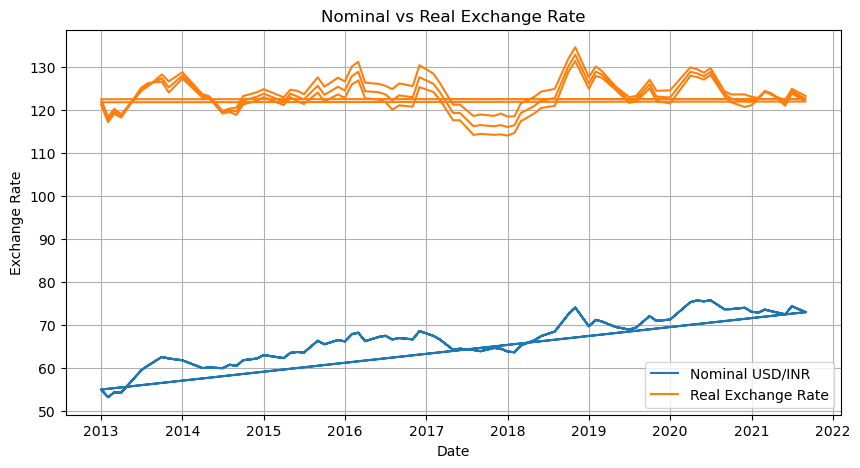

In [27]:
plt.figure(figsize=(10,5))

plt.plot(combined['date'], combined['Close'], label='Nominal USD/INR')
plt.plot(combined['date'], combined['Real_Exchange_Rate'], label='Real Exchange Rate')

plt.legend()
plt.title("Nominal vs Real Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.grid()
plt.show()